# Résolution de jeux combinatoires — Puissance 4
## Minimax / α-β · MCTS · DQN — comparaison empirique

**L3 — Résolution de jeux combinatoires par minimax et alpha-beta**

Ce notebook compare trois familles de joueurs artificiels sur le **Puissance 4**
(plateau 6×7, jeu à information complète, somme nulle) :

1. **Minimax avec élagage α-β**, table de transposition et heuristique — recherche exacte.
2. **MCTS** (Monte Carlo Tree Search) avec politique **UCB1** — recherche stochastique.
3. **DQN** (Deep Q-Network) entraîné par self-play — approche par apprentissage.

Il raconte une histoire en trois temps : *(i)* on rend l'**élagage α-β visible**
(Knuth & Moore 1975), *(ii)* on organise un **tournoi round-robin** et on lit la
hiérarchie des forces, *(iii)* on **joue interactivement** contre chaque agent en
observant « ce qu'il pense ». L'analyse finale répond à : *dans quelles situations
chaque méthode excelle ?*

> Tout le code algorithmique vit dans les modules `game/`, `agents/`, `tournament/`,
> `viz/`. Ce notebook ne fait qu'**appeler** et **visualiser**. La suite `pytest`
> (`tests/`) valide le moteur et les agents.

## 0. Configuration et imports

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath("."))  # importer les modules depuis la racine

import numpy as np
import matplotlib.pyplot as plt

from game.connect_four import ConnectFour
from agents.random_agent import RandomAgent
from agents.alphabeta import AlphaBetaAgent
from agents.mcts import MCTSAgent
from agents.dqn import DQNAgent, QNetwork, DEVICE
from tournament.runner import run_tournament, play_match, strength_vs_budget

from viz.style import apply_style
from viz import pruning, tournament_viz, board

apply_style()  # palette cohérente, lisible en présentation
SEED = 42
print("Device PyTorch :", DEVICE)

/home/ested/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Device PyTorch : cpu


## 1. Le moteur de jeu

Le plateau (`game/connect_four.py`) gère la gravité, la détection de victoire dans
les quatre directions, et un **hash de Zobrist** mis à jour de façon incrémentale
(un seul XOR par coup) — c'est la clé qui indexe les **tables de transposition**
de l'agent α-β. La ligne 0 est le **bas** du plateau.

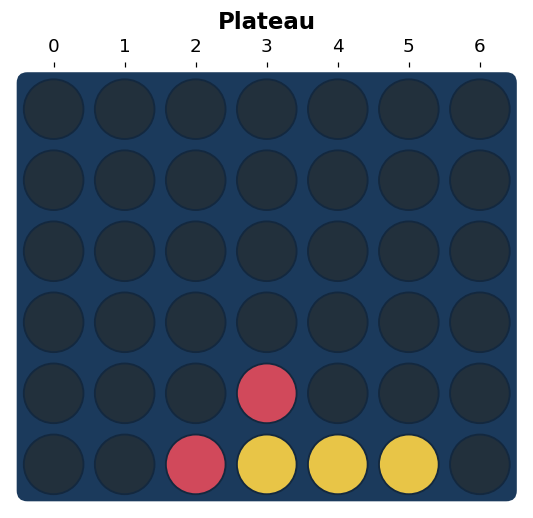

Coups légaux : [0, 1, 2, 3, 4, 5, 6]
Hash de Zobrist : 11930676605620801507
Joueur au trait : 2 (1 = jaune, 2 = rouge)


In [2]:
g = ConnectFour()
for coup in [3, 3, 4, 2, 5]:
    g.play_move(coup)

board.draw_board(g)
plt.show()
print("Coups légaux :", g.legal_moves())
print("Hash de Zobrist :", g.zobrist_hash)
print("Joueur au trait :", g.current_player, "(1 = jaune, 2 = rouge)")

## 2. Baseline : l'agent aléatoire

`RandomAgent` joue uniformément parmi les coups légaux. Il valide la boucle de jeu
et sert d'**étalon** : tout agent « intelligent » doit le battre nettement.

In [3]:
a, b = RandomAgent(seed=1), RandomAgent(seed=2)
out = play_match(a, b, n_games=20)
print("Random vs Random (20 parties) :", out)

Random vs Random (20 parties) : {'wins_a': 9, 'wins_b': 11, 'draws': 0}


## 3. Minimax avec élagage α-β

**Idée.** Minimax explore l'arbre des coups en supposant que chaque joueur joue au
mieux. L'**élagage α-β** maintient deux bornes (α = meilleur garanti pour Max, β =
meilleur garanti pour Min) : dès qu'un coup prouve qu'une branche ne pourra pas
être choisie, on l'**abandonne sans l'explorer**. Le résultat est *identique* à
minimax, mais le coût peut chuter de plusieurs ordres de grandeur (Knuth & Moore 1975).

On y ajoute :
- une **fonction d'évaluation** (alignements de 2/3 jetons, contrôle du centre) pour
  les positions non terminales ;
- une **table de transposition** (indexée par le hash de Zobrist) pour réutiliser
  les positions déjà évaluées ;
- un **move ordering** (colonnes centrales d'abord) qui provoque les coupures plus tôt.

L'agent expose des compteurs (`nodes`, `cutoffs`, `tt_hits`) et chaque optimisation
est **activable indépendamment** — c'est ce qui permet la visualisation ci-dessous.

###  Visualisation clé n°1 — l'élagage α-β rendu visible

À gauche, l'arbre de recherche sur une position donnée : les **branches rouges (✗)**
sont celles que α-β a **coupées** (jamais explorées). À droite, le **nombre de nœuds
explorés** selon les optimisations : à résultat identique, chaque ajout réduit
drastiquement le travail.

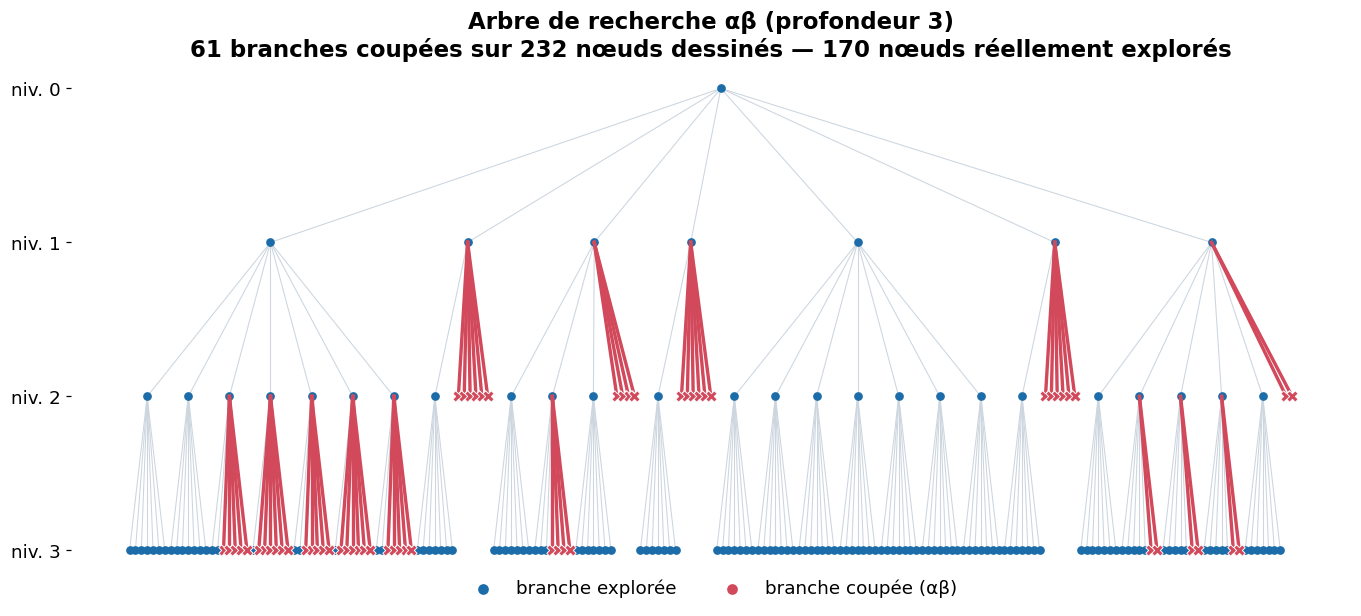

In [4]:
position = ConnectFour()
for coup in [3, 3, 4, 2]:
    position.play_move(coup)

fig, ax = plt.subplots(figsize=(15, 6))
pruning.plot_search_tree(position, depth=3, ax=ax)
plt.show()

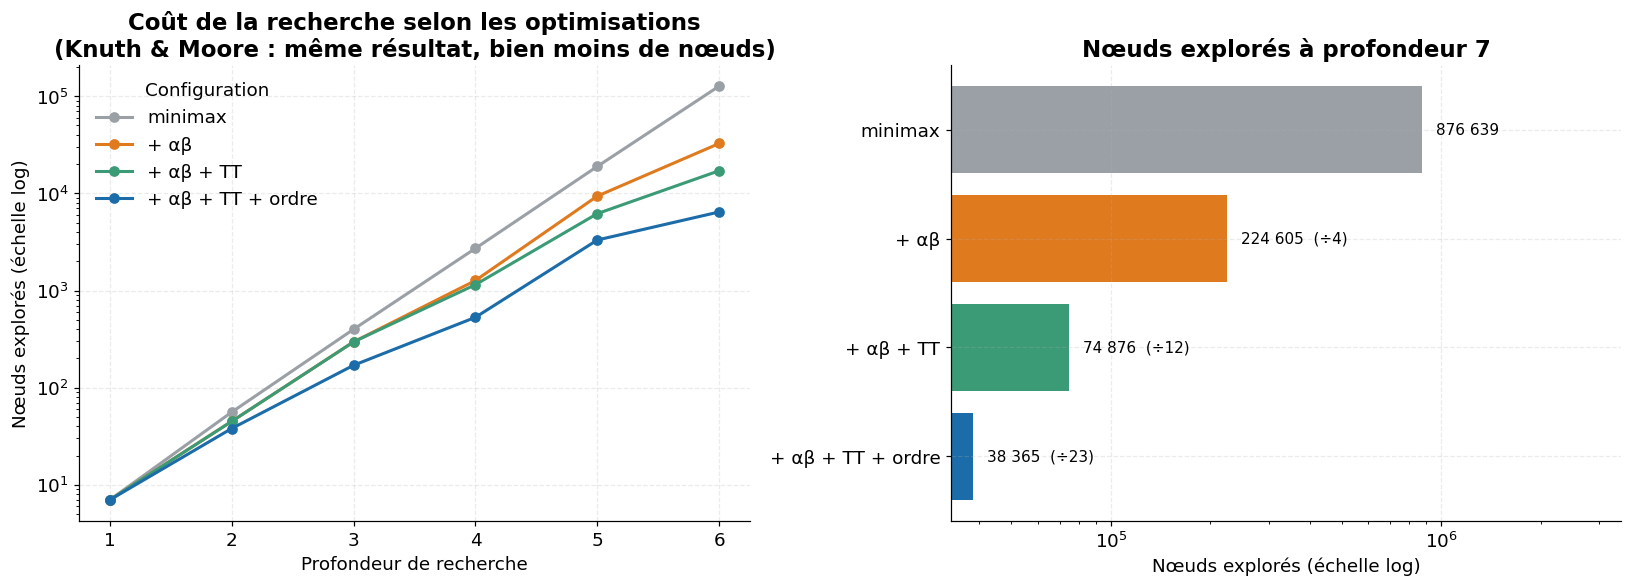

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
pruning.plot_nodes_vs_depth(position, depths=[1, 2, 3, 4, 5, 6], ax=ax1)
pruning.plot_pruning_comparison(position, depth=7, ax=ax2)
plt.tight_layout()
plt.show()

**Lecture.** L'échelle est logarithmique. `minimax` pur croît comme ≈ 7^profondeur ;
α-β seul gagne déjà un ordre de grandeur, la table de transposition et le move
ordering encore davantage. Les tests (`tests/test_alphabeta.py`) garantissent que
**toutes les variantes renvoient la même valeur** : on ne change que le *coût*, pas
le *résultat*. C'est exactement le théorème de Knuth & Moore rendu tangible.

## 4. Monte Carlo Tree Search (UCB1)

**Idée.** Au lieu d'explorer exhaustivement, MCTS construit un arbre par milliers de
**simulations**. Chaque simulation = sélection (descendre via **UCB1**, qui équilibre
exploitation et exploration), expansion, *rollout* aléatoire jusqu'à la fin, puis
rétropropagation du résultat. Le coup joué est le **plus visité** (le plus robuste).

MCTS ne nécessite **pas de fonction d'évaluation** : il « devine » la valeur par
échantillonnage. Son budget est réglable (nombre de simulations ou temps).

MCTS (3000 simulations) choisit la colonne 5


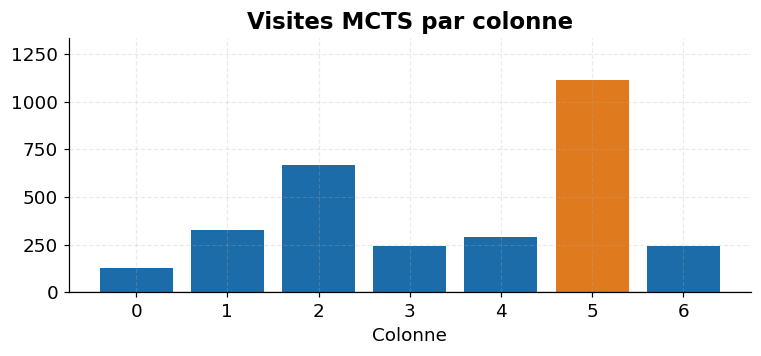

In [6]:
position = ConnectFour()
for coup in [3, 3, 4]:
    position.play_move(coup)

mcts = MCTSAgent(n_simulations=3000, seed=SEED)
coup = mcts.move(position)
print(f"MCTS (3000 simulations) choisit la colonne {coup}")

scores, label = board.agent_thoughts(mcts, position)
fig, ax = plt.subplots(figsize=(8, 3))
board.draw_thoughts(scores, label, ax=ax)
plt.show()

Les barres montrent **combien de fois** MCTS a exploré chaque colonne : il concentre
son budget sur les coups prometteurs (exploitation) tout en sondant les autres
(exploration). C'est sa façon de « penser ».

## 5. DQN — apprentissage par renforcement (self-play)

**Idée.** Un réseau de neurones (petit CNN) apprend une fonction **Q(état, colonne)**
estimant la valeur de chaque coup. Entraînement par **self-play** : l'agent joue
contre lui-même, stocke ses transitions dans un *replay buffer*, et apprend par
descente de gradient vers une **cible negamax** (jeu à somme nulle : la valeur de
l'état suivant pour nous est l'opposé de la meilleure valeur de l'adversaire).

L'état est encodé **canoniquement** (2 canaux : mes jetons / ceux de l'adversaire,
toujours du point de vue du joueur au trait). Objectif minimal : **battre nettement
le hasard**. Le modèle est pré-entraîné (`scripts/train_dqn.py`) et chargé ici.

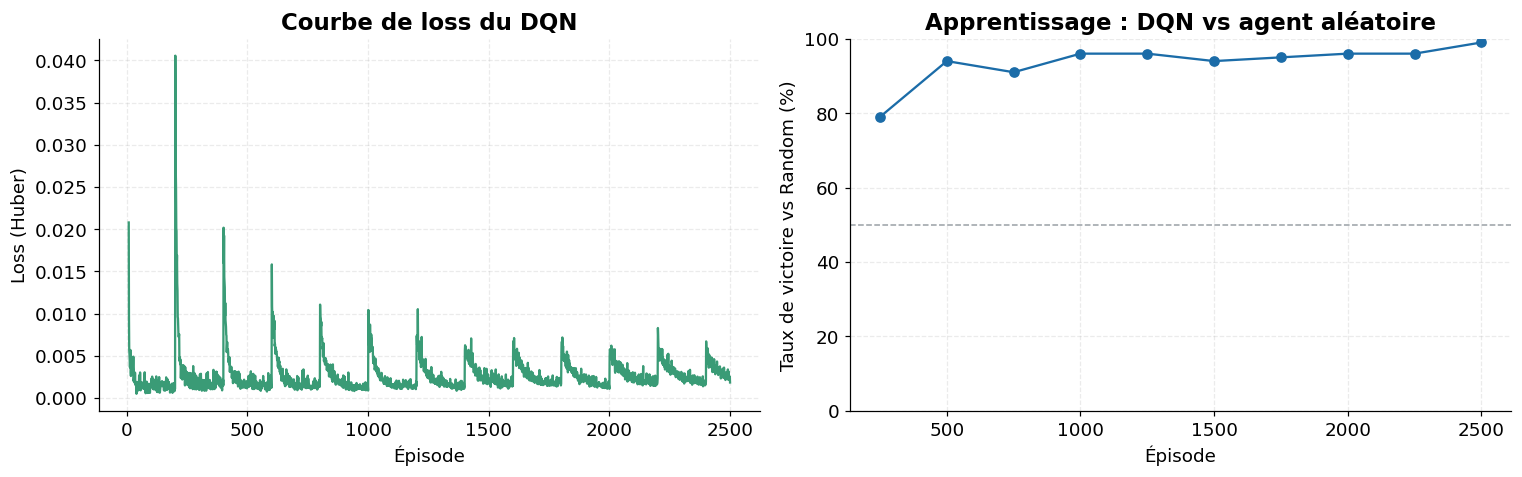

Taux de victoire final vs Random : 99%


In [7]:
dqn = DQNAgent(QNetwork(), name="DQN")
dqn.load("models/dqn.pt")

# Courbes d'entraînement sauvegardées.
hist = np.load("models/dqn_history.npz")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.plot(hist["steps"], hist["losses"], color="#3a9b76")
ax1.set_xlabel("Épisode"); ax1.set_ylabel("Loss (Huber)")
ax1.set_title("Courbe de loss du DQN")
ax2.plot(hist["eval_episodes"], hist["winrate_vs_random"] * 100, marker="o", color="#1b6ca8")
ax2.axhline(50, color="#9aa0a6", ls="--", lw=1)
ax2.set_xlabel("Épisode"); ax2.set_ylabel("Taux de victoire vs Random (%)")
ax2.set_ylim(0, 100); ax2.set_title("Apprentissage : DQN vs agent aléatoire")
plt.tight_layout(); plt.show()
print(f"Taux de victoire final vs Random : {hist['winrate_vs_random'][-1]:.0%}")

Le DQN dépasse rapidement **90 %** de victoires contre le hasard : l'objectif minimal
du sujet est atteint avec marge, **sans pivoter** vers un AlphaZero-lite. On verra
toutefois dans le tournoi qu'apprendre à battre le hasard ne suffit pas à rivaliser
tactiquement avec α-β.

## 6. Tournoi round-robin — visualisation clé n°2

Chaque paire d'agents s'affronte sur plusieurs parties, en **alternant qui commence**
(le premier joueur a un avantage au Puissance 4). On mesure le **score** et le
**temps de réflexion par coup**.

In [8]:
dqn_agent = DQNAgent(QNetwork(), name="DQN"); dqn_agent.load("models/dqn.pt")
agents = [
    AlphaBetaAgent(depth=5, name="AlphaBeta"),
    MCTSAgent(n_simulations=600, seed=SEED, name="MCTS"),
    dqn_agent,
    RandomAgent(seed=SEED),
]
agents[3].name = "Random"

resultats = run_tournament(agents, n_games=12, verbose=True)
print("\nClassement :", sorted(resultats.total_score.items(), key=lambda kv: -kv[1]))

AlphaBeta vs MCTS : 7 - 5 (nuls 0)
AlphaBeta vs DQN : 12 - 0 (nuls 0)
AlphaBeta vs Random : 12 - 0 (nuls 0)
MCTS vs DQN : 12 - 0 (nuls 0)
MCTS vs Random : 12 - 0 (nuls 0)
DQN vs Random : 12 - 0 (nuls 0)

Classement : [('AlphaBeta', 31.0), ('MCTS', 29.0), ('DQN', 12.0), ('Random', 0.0)]


###  Heatmap des forces et compromis vitesse/force

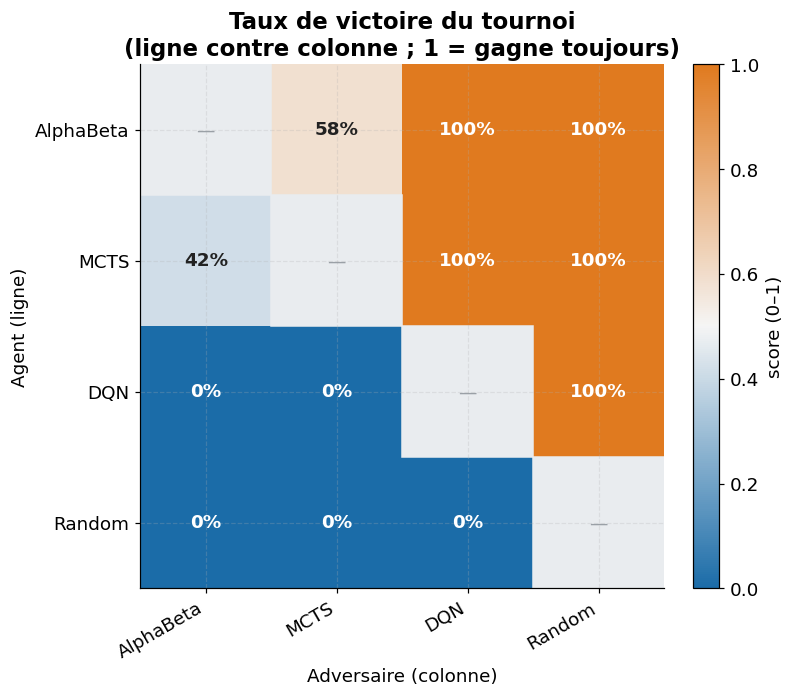

In [9]:
fig, ax = plt.subplots(figsize=(8, 6.5))
tournament_viz.plot_winrate_heatmap(resultats, ax=ax)
plt.tight_layout(); plt.show()

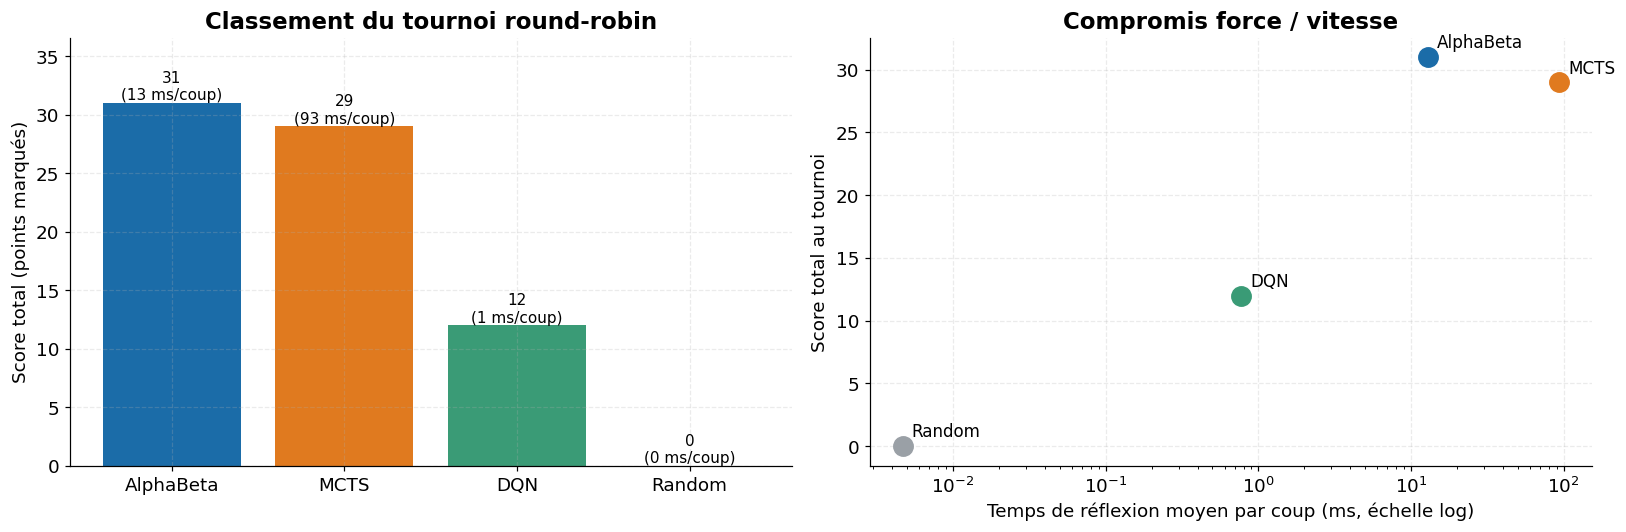

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
tournament_viz.plot_ranking(resultats, ax=ax1)
tournament_viz.plot_speed_vs_strength(resultats, ax=ax2)
plt.tight_layout(); plt.show()

### Force vs budget de temps alloué

Le sujet pose une question fine : *qui domine selon l'horizon de réflexion ?* On fait
varier le **budget de temps par coup** de MCTS et la **profondeur** d'α-β, contre un
adversaire fixe (MCTS de référence), pour voir comment la force évolue avec le budget.

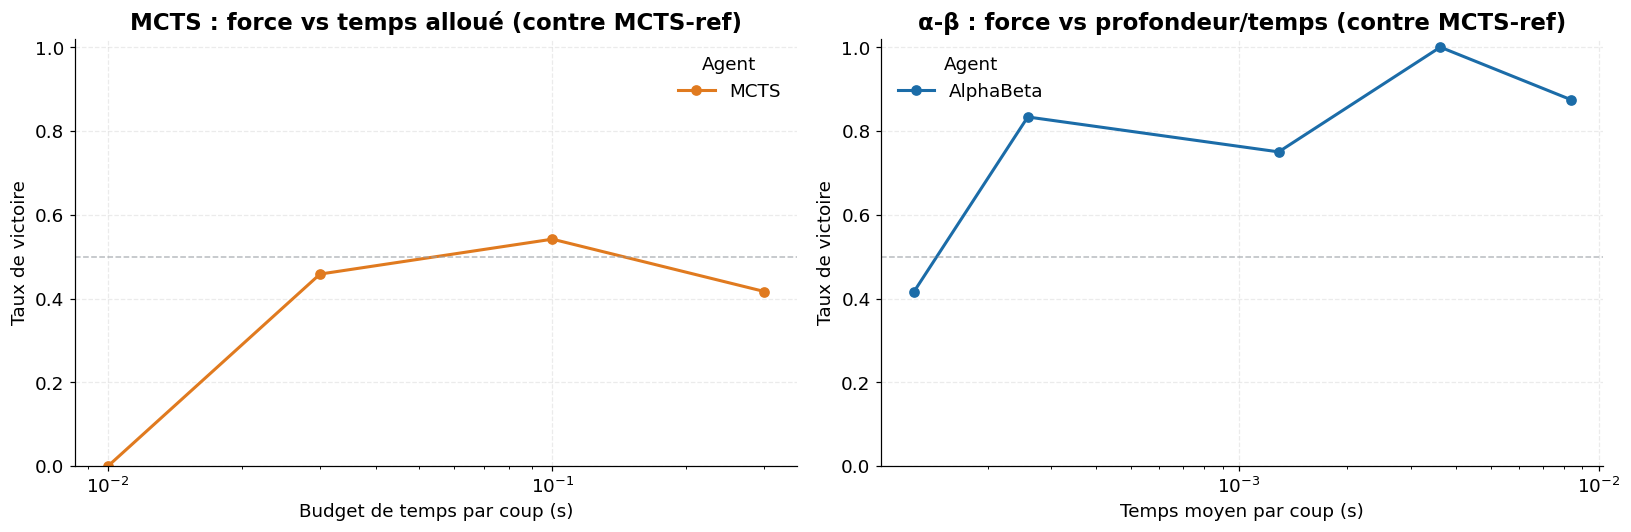

In [11]:
budgets_temps = [0.01, 0.03, 0.1, 0.3]
adversaire = MCTSAgent(n_simulations=300, seed=7, name="MCTS-ref")

courbe_mcts = strength_vs_budget(
    lambda t: MCTSAgent(time_budget=t, seed=SEED, name="MCTS"),
    adversaire, budgets=budgets_temps, n_games=12,
)
# Pour α-β on convertit profondeur -> temps mesuré pour aligner les abscisses.
import time
courbe_ab, temps_ab = [], []
for d in [1, 2, 3, 4, 5]:
    ab = AlphaBetaAgent(depth=d, name="AlphaBeta")
    pos = ConnectFour(); pos.play_move(3)
    t0 = time.perf_counter(); ab.move(pos); temps_ab.append(time.perf_counter() - t0)
    out = play_match(ab, adversaire, n_games=12)
    courbe_ab.append((out["wins_a"] + 0.5 * out["draws"]) / 12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
tournament_viz.plot_strength_vs_budget(
    budgets_temps, {"MCTS": courbe_mcts},
    xlabel="Budget de temps par coup (s)", ax=ax1)
ax1.set_title("MCTS : force vs temps alloué (contre MCTS-ref)")
tournament_viz.plot_strength_vs_budget(
    temps_ab, {"AlphaBeta": courbe_ab},
    xlabel="Temps moyen par coup (s)", ax=ax2)
ax2.set_title("α-β : force vs profondeur/temps (contre MCTS-ref)")
plt.tight_layout(); plt.show()

**Lecture.** À budget très serré, MCTS reste correct car même peu de simulations
captent les menaces immédiates. Quand on laisse du temps, **α-β en profondeur prend
l'ascendant** : sa recherche exacte + heuristique calcule des séquences forcées que
les rollouts aléatoires de MCTS estiment mal.

## 7. Visualisation clé n°3 — jouez contre un agent

Choisissez un adversaire dans le menu et cliquez sur une colonne pour jouer. Sous le
plateau s'affiche **ce que pense l'agent** : évaluation par colonne (α-β), visites
(MCTS) ou Q-valeurs (DQN). *(Nécessite un noyau Jupyter actif avec ipywidgets ;
l'export statique n'est pas interactif.)*

In [ ]:
from viz.interactive import InteractiveGame

dqn_play = DQNAgent(QNetwork(), name="DQN"); dqn_play.load("models/dqn.pt")
jeu = InteractiveGame({
    "AlphaBeta (profondeur 5)": AlphaBetaAgent(depth=5),
    "MCTS (1500 simulations)": MCTSAgent(n_simulations=1500, seed=SEED),
    "DQN": dqn_play,
})
jeu.show()

## 8. Analyse — dans quelles situations chaque méthode excelle ?

En s'appuyant sur les visualisations ci-dessus :

| Méthode | Excelle quand… | Limite |
|---|---|---|
| **α-β** | l'horizon est **tactique et calculable** : séquences forcées, gains/pertes à quelques coups. À budget moyen/long, **domine le tournoi** (heatmap) grâce à l'élagage qui rend une grande profondeur abordable. | dépend de la **qualité de l'heuristique** ; coût explosif sans table de transposition / move ordering (viz n°1). |
| **MCTS** | le budget est **serré** ou l'arbre trop large pour une recherche exacte ; **aucune heuristique** à concevoir. Compétitif à faible temps (courbe force/budget). | les *rollouts* aléatoires **estiment mal** les séquences forcées étroites ; variance élevée à petit budget. |
| **DQN** | l'**inférence doit être quasi-instantanée** (le plus rapide par coup, cf. compromis vitesse/force) et bat **nettement le hasard** après self-play. | n'**anticipe pas** explicitement : dépassé tactiquement par α-β/MCTS ; coûteux à *entraîner*, sensible aux hyperparamètres. |

**Synthèse.** Sur le Puissance 4, jeu tactique à faible facteur de branchement,
**la recherche exacte (α-β) domine dès qu'on lui donne de la profondeur**, et
l'élagage de Knuth & Moore est précisément ce qui rend cette profondeur atteignable.
**MCTS** est le bon compromis quand le temps manque ou qu'aucune heuristique n'est
disponible. **Le DQN** illustre une troisième voie — rapide et sans recherche à
l'inférence — mais, entraîné seulement à battre le hasard, il ne rivalise pas encore
tactiquement : le faire progresser demanderait un guidage par recherche
(**AlphaZero-lite** : policy+value guidant MCTS), piste naturelle d'extension.

> Reproductibilité : graines fixes, modèle DQN versionné (`models/dqn.pt`), et suite
> `pytest` validant moteur + agents + visualisations.